In [20]:
tickers = ["TATASTEEL.NS", "JSWSTEEL.NS", "SAIL.NS"]

In [21]:
import yfinance as yf

stock = yf.Ticker(tickers[0])
bs = stock.balance_sheet
fin = stock.financials

print(bs.index.tolist())
print(fin.index.tolist())

['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued', 'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital', 'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations', 'Common Stock Equity', 'Total Capitalization', 'Total Equity Gross Minority Interest', 'Minority Interest', 'Stockholders Equity', 'Other Equity Interest', 'Retained Earnings', 'Additional Paid In Capital', 'Capital Stock', 'Common Stock', 'Total Liabilities Net Minority Interest', 'Total Non Current Liabilities Net Minority Interest', 'Other Non Current Liabilities', 'Derivative Product Liabilities', 'Non Current Pension And Other Postretirement Benefit Plans', 'Tradeand Other Payables Non Current', 'Non Current Deferred Revenue', 'Non Current Deferred Taxes Liabilities', 'Long Term Debt And Capital Lease Obligation', 'Long Term Capital Lease Obligation', 'Long Term Debt', 'Long Term Provisions', 'Current Liabilities', 'Other Current Liabilities', 'Current Debt And Capital Lease 

In [22]:
import pandas as pd

def get_ccc(ticker):
    stock = yf.Ticker(ticker)
    bs = stock.balance_sheet
    fin = stock.financials

    latest_bs = bs.columns[0]
    latest_fin = fin.columns[0]

    inventory = bs.loc['Inventory', latest_bs] if 'Inventory' in bs.index else None
    receivables = bs.loc['Accounts Receivable', latest_bs] if 'Accounts Receivable' in bs.index else None
    payables = bs.loc['Accounts Payable', latest_bs] if 'Accounts Payable' in bs.index else None

    revenue = fin.loc['Total Revenue', latest_fin] if 'Total Revenue' in fin.index else None
    cogs = fin.loc['Cost Of Revenue', latest_fin] if 'Cost Of Revenue' in fin.index else None

    if None in [inventory, receivables, payables, revenue, cogs]:
        return None

    dio = (inventory / cogs) * 365
    dso = (receivables / revenue) * 365
    dpo = (payables / cogs) * 365
    ccc = dio + dso - dpo

    return {'DIO': round(dio,1), 'DSO': round(dso,1), 'DPO': round(dpo,1), 'CCC': round(ccc,1)}

In [23]:
results = {}
for t in tickers:
    r = get_ccc(t)
    if r:
        results[t] = r
    else:
        print(f"Missing data for {t} — check row names from Step 2")

df = pd.DataFrame(results).T
print(df)

                DIO   DSO    DPO   CCC
TATASTEEL.NS  140.1   7.8  103.2  44.7
JSWSTEEL.NS   106.0  22.6   50.4  78.2
SAIL.NS       125.0  21.6   57.8  88.8


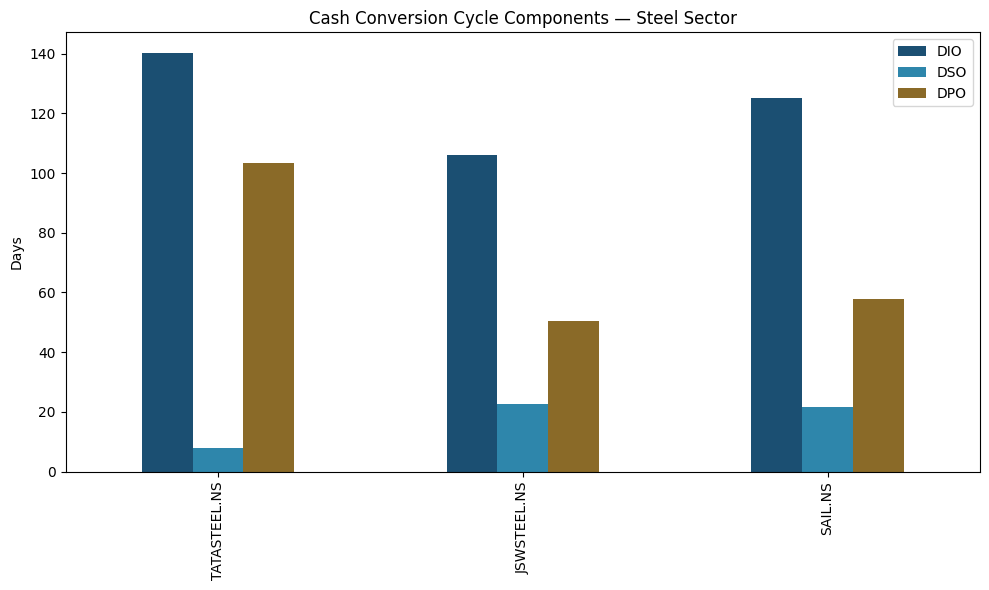

In [24]:
import matplotlib.pyplot as plt

df[['DIO','DSO','DPO']].plot(kind='bar', figsize=(10,6), color=['#1B4F72','#2E86AB','#8A6A28'])
plt.title('Cash Conversion Cycle Components — Steel Sector')
plt.ylabel('Days')
plt.tight_layout()
plt.savefig('working_capital_comparison.png')
plt.show()